In [ ]:
#verify the environment path
import sys
print(sys.executable)

d:\underwater-object-detection\venv\Scripts\python.exe


In [ ]:
# initial dataset exploration
from pathlib import Path
import json

#check folders project root and dafault to parent folder if execuation is in subfolder
PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()
#define paths to DUO dataset and annotations
DUO_ROOT = PROJECT_ROOT / "data" / "raw" / "DUO"
ANNOTATION_DIR = DUO_ROOT / "annotations"

#define paths to train and test annotation files
train_json = ANNOTATION_DIR / "instances_train.json"
test_json = ANNOTATION_DIR / "instances_test.json"

#print paths and verify that the annotation files exist
print("Project root:", PROJECT_ROOT.resolve())
print("DUO root:", DUO_ROOT.resolve())
print("Train annotations found:", train_json.exists())
print("Test annotations found:", test_json.exists())

Project root: D:\underwater-object-detection
DUO root: D:\underwater-object-detection\data\raw\DUO
Train annotations found: True
Test annotations found: True


In [ ]:
with train_json.open("r", encoding="utf-8") as file: # open the train annotation file and load the JSON data
    train_data = json.load(file)

with test_json.open("r", encoding="utf-8") as file: #open test annotation file
    test_data = json.load(file)

print("Training images:", len(train_data["images"])) #print the number of training images and annotations
print("Training annotations:", len(train_data["annotations"]))
print("Test images:", len(test_data["images"])) #print the number of test images and annotations
print("Test annotations:", len(test_data["annotations"]))

print("\nCategories:") # print header for the categories section
for category in train_data["categories"]:
    print(category)

Training images: 6671
Training annotations: 63998
Test images: 1111
Test annotations: 10517

Categories:
{'name': 'holothurian', 'id': 1}
{'name': 'echinus', 'id': 2}
{'name': 'scallop', 'id': 3}
{'name': 'starfish', 'id': 4}


In [ ]:
#working out class distribution using Counter and pandas DataFrame
from collections import Counter
import pandas as pd

category_lookup = { #dictionary to map category IDs to names
    category["id"]: category["name"]
    for category in train_data["categories"]
}

train_class_counts = Counter( # count the number of training annotations for each class
    category_lookup[annotation["category_id"]]
    for annotation in train_data["annotations"]
)

test_class_counts = Counter( # count the number of test annotations for each class

    category_lookup[annotation["category_id"]]
    for annotation in test_data["annotations"]
)

class_table = pd.DataFrame({ # create a DataFrame to display the class distribution
    "Class": list(category_lookup.values()),
    "Training objects": [
        train_class_counts[name]
        for name in category_lookup.values()
    ],
    "Test objects": [ # create a list of test object counts for each class
        test_class_counts[name]
        for name in category_lookup.values()
    ],
})

class_table["Total objects"] = ( # calculate the total number of objects for each class by summing training and test objects
    class_table["Training objects"]
    + class_table["Test objects"]
)

class_table["Training percentage"] = ( # calculate the percentage of training objects for each class
    class_table["Training objects"]
    / class_table["Training objects"].sum()
    * 100
).round(2)

class_table # display the class distribution table

,Class,Training objects,Test objects,Total objects,Training percentage
0,holothurian,6808,1079,7887,10.64
1,echinus,42955,7201,50156,67.12
2,scallop,1707,217,1924,2.67
3,starfish,12528,2020,14548,19.58


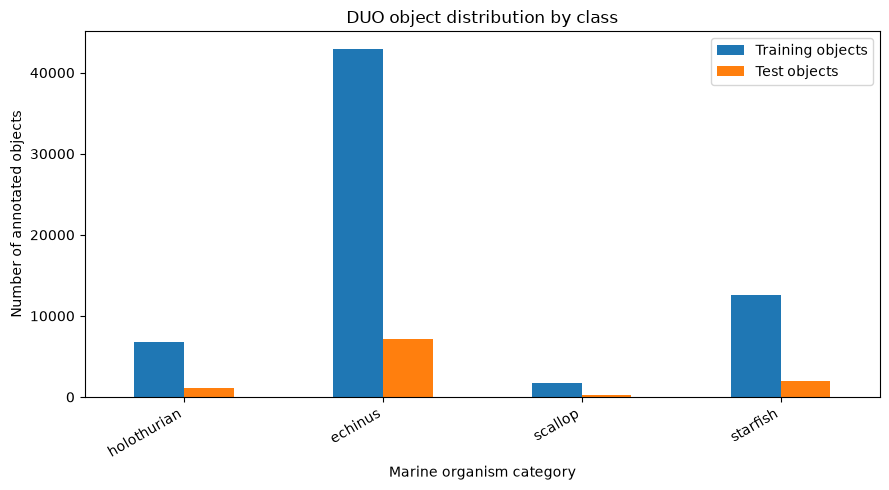

In [ ]:
#plotting distribution
import matplotlib.pyplot as plt

ax = class_table.plot( #create a bar plot to visualize the class distribution
    x="Class",
    y=["Training objects", "Test objects"],
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("DUO object distribution by class") #set the title of the plot
ax.set_xlabel("Marine organism category") #set the x-axis label of the plot
ax.set_ylabel("Number of annotated objects") #set the y-axis label of the plot

plt.xticks(rotation=30, ha="right") #rotate the x-axis tick labels for better readability
plt.tight_layout() #adjust the layout of the plot to prevent overlapping elements
plt.show() #display the plot

In [ ]:
#checking JSON image records match actual images
for item in DUO_ROOT.iterdir():
    print(item.name)

    image_extensions = {".jpg", ".jpeg", ".png"} # define a set of valid image file extensions

actual_images = { # create a set of actual image filenames
    path.name
    for path in DUO_ROOT.rglob("*") # recursively search for all files in the DUO_ROOT directory and its subdirectories
    if path.is_file() and path.suffix.lower() in image_extensions # filter for image files
}

json_filenames = { # create a set of image filenames referenced in the JSON annotation files
    image["file_name"]
    for image in train_data["images"] + test_data["images"]
}

missing_images = sorted(json_filenames - actual_images) # find image files referenced in JSON but missing in the actual dataset
unreferenced_images = sorted(actual_images - json_filenames) # find image files present in the dataset but not referenced in the JSON annotation files

print("Images referenced in JSON:", len(json_filenames)) # print the number of image files referenced in the JSON annotation files
print("Actual images found:", len(actual_images)) # print the number of actual image files found in the dataset
print("Missing image files:", len(missing_images)) # print the number of image files that are referenced in the JSON annotation files but missing in the actual dataset
print("Unreferenced image files:", len(unreferenced_images)) # print the number of image files that are present in the dataset but not referenced in the JSON annotation files

print("First missing examples:", missing_images[:10]) # print the first 10 image filenames that are referenced in the JSON annotation files but missing in the actual dataset

images
annotations
.DS_Store
README.txt
Images referenced in JSON: 6671
Actual images found: 6671
Missing image files: 0
Unreferenced image files: 0
First missing examples: []


In [ ]:
#checking bounding boxes
def check_annotations(data):
    image_lookup = {
        image["id"]: image
        for image in data["images"]
    }
 
    invalid_boxes = [] # list to store invalid bounding box information

    for annotation in data["annotations"]: # iterate through each annotation in the dataset
        image = image_lookup[annotation["image_id"]] # retrieve the corresponding image information for the annotation
        x, y, width, height = annotation["bbox"] # unpack the bounding box coordinates and dimensions from the annotation

        invalid = ( # check if the bounding box is invalid
            width <= 0
            or height <= 0
            or x < 0
            or y < 0
            or x + width > image["width"]
            or y + height > image["height"]
        )

        if invalid: # if the bounding box is invalid, append its information to the invalid_boxes list
            invalid_boxes.append({ #store the annotation ID, image ID, bounding box coordinates, and image size for the invalid bounding box
                "annotation_id": annotation["id"],
                "image_id": annotation["image_id"],
                "bbox": annotation["bbox"],
                "image_size": (
                    image["width"],
                    image["height"],
                ),
            })

    return invalid_boxes #return the list of invalid bounding boxes


invalid_train = check_annotations(train_data) #check the training dataset for invalid bounding boxes
invalid_test = check_annotations(test_data) # check the test dataset for invalid bounding boxes

print("Invalid training boxes:", len(invalid_train))
print("Invalid test boxes:", len(invalid_test))

Invalid training boxes: 847
Invalid test boxes: 106


In [ ]:
#checking how far boxes are outside the image bounds
def inspect_invalid_annotations(data): # define a function to inspect invalid annotations in the dataset
    image_lookup = { # create a lookup dictionary to map image IDs to image information
        image["id"]: image
        for image in data["images"] 
    }

    invalid = [] # list to store detailed information about invalid annotations

    for annotation in data["annotations"]: # iterate through each annotation in the dataset
        image = image_lookup[annotation["image_id"]]
        x, y, width, height = annotation["bbox"]

        overflow_left = max(0, -x) # calculate the amount of overflow of the bounding box
        overflow_top = max(0, -y)
        overflow_right = max(
            0,
            x + width - image["width"] 
        )
        overflow_bottom = max( # calculate the amount of overflow of the bounding box on the bottom side
            0,
            y + height - image["height"] 
        )

        if ( # check if the bounding box is invalid based on its dimensions and overflow
            width <= 0
            or height <= 0
            or overflow_left > 0
            or overflow_top > 0
            or overflow_right > 0
            or overflow_bottom > 0
        ):
            invalid.append({ # store info  about the invalid annotation, including its ID, image ID, file name, bounding box coordinates, image dimensions, and overflow amounts
                "annotation_id": annotation["id"],
                "image_id": annotation["image_id"],
                "file_name": image["file_name"],
                "bbox": annotation["bbox"],
                "image_width": image["width"],
                "image_height": image["height"],
                "overflow_left": overflow_left,
                "overflow_top": overflow_top,
                "overflow_right": overflow_right,
                "overflow_bottom": overflow_bottom,
            })

    return invalid # return the list of invalid annotations with detailed information


invalid_train_details = inspect_invalid_annotations(train_data) # inspect the training dataset for invalid annotations and store detailed information
invalid_test_details = inspect_invalid_annotations(test_data) # inspect the test dataset for invalid annotations and store detailed information

invalid_train_details[:10] # display the first 10 invalid annotations in the training dataset with detailed information

[{'annotation_id': 16,
  'image_id': 2,
  'file_name': '2.jpg',
  'bbox': [501, 289, 205, 117],
  'image_width': 720,
  'image_height': 405,
  'overflow_left': 0,
  'overflow_top': 0,
  'overflow_right': 0,
  'overflow_bottom': 1},
 {'annotation_id': 17,
  'image_id': 2,
  'file_name': '2.jpg',
  'bbox': [610, 105, 111, 102],
  'image_width': 720,
  'image_height': 405,
  'overflow_left': 0,
  'overflow_top': 0,
  'overflow_right': 1,
  'overflow_bottom': 0},
 {'annotation_id': 19,
  'image_id': 2,
  'file_name': '2.jpg',
  'bbox': [364, 255, 188, 151],
  'image_width': 720,
  'image_height': 405,
  'overflow_left': 0,
  'overflow_top': 0,
  'overflow_right': 0,
  'overflow_bottom': 1},
 {'annotation_id': 22,
  'image_id': 2,
  'file_name': '2.jpg',
  'bbox': [686, 168, 35, 114],
  'image_width': 720,
  'image_height': 405,
  'overflow_left': 0,
  'overflow_top': 0,
  'overflow_right': 1,
  'overflow_bottom': 0},
 {'annotation_id': 132,
  'image_id': 9,
  'file_name': '9.jpg',
  'bbox'

In [ ]:
#checking max overflow values
import pandas as pd

invalid_train_df = pd.DataFrame(invalid_train_details) # create a DataFrame from the list of invalid training annotations with detailed information
invalid_test_df = pd.DataFrame(invalid_test_details)

display( # display descriptive statistics for the invalid training annotations
    invalid_train_df[
        [
            "overflow_left",
            "overflow_top",
            "overflow_right",
            "overflow_bottom",
        ]
    ].describe()
)

display( # display descriptive statistics for the invalid test annotations
    invalid_test_df[
        [
            "overflow_left",
            "overflow_top",
            "overflow_right",
            "overflow_bottom",
        ]
    ].describe()
)

#from results below, we can see max overflow boxes are onl;y exceeding the image boundary by a max of 1 pixel so no boxes overextend beyong the image by more than 1 pixel. This is likely due to rounding errors in the annotation process and should not significantly affect model training or evaluation.. this same pattern is also seen in both training and test datasets. Therefore, we can conclude that the bounding boxes are generally well-defined and do not significantly exceed the image boundaries. 

,overflow_left,overflow_top,overflow_right,overflow_bottom
count,847.0,847.0,847.000000,847.000000
mean,0.0,0.0,0.251476,0.766234
std,0.0,0.0,0.434118,0.423475
min,0.0,0.0,0.000000,0.000000
25%,0.0,0.0,0.000000,1.000000
50%,0.0,0.0,0.000000,1.000000
75%,0.0,0.0,1.000000,1.000000
max,0.0,0.0,1.000000,1.000000


,overflow_left,overflow_top,overflow_right,overflow_bottom
count,106.0,106.0,106.000000,106.000000
mean,0.0,0.0,0.301887,0.726415
std,0.0,0.0,0.461257,0.447916
min,0.0,0.0,0.000000,0.000000
25%,0.0,0.0,0.000000,0.000000
50%,0.0,0.0,0.000000,1.000000
75%,0.0,0.0,1.000000,1.000000
max,0.0,0.0,1.000000,1.000000


In [ ]:
#checking if boxes have negative width or height
def count_invalid_dimensions(data):
    zero_or_negative = []

    for annotation in data["annotations"]: # iterate through each annotation in the dataset
        _, _, width, height = annotation["bbox"]

        if width <= 0 or height <= 0:
            zero_or_negative.append(annotation)

    return  # return the list of annotations with non-positive dimensions


bad_dimensions_train = count_invalid_dimensions(train_data) # check the training dataset for annotations with non-positive dimensions
bad_dimensions_test = count_invalid_dimensions(test_data) # check the test dataset for annotations with non-positive dimensions

print(
    "Training boxes with non-positive dimensions:",
    len(bad_dimensions_train)
)

print(
    "Test boxes with non-positive dimensions:",
    len(bad_dimensions_test)
)

Training boxes with non-positive dimensions: 0
Test boxes with non-positive dimensions: 0


In [ ]:
#CLEANING CODE
from copy import deepcopy # import deepcopy to create a deep copy of the dataset to avoid modifying the original data
from pathlib import Path # import Path from pathlib to handle file paths
import json # import json to read and write JSON files


def clean_coco_annotations(data): # define a function to clean COCO annotations by clipping bounding boxes to image boundaries and removing invalid boxes
    cleaned_data = deepcopy(data) # create a deep copy of the dataset to avoid modifying the original data

    image_lookup = { # create a lookup dictionary to map image IDs to image information
        image["id"]: image
        for image in cleaned_data["images"]
    }

    cleaned_annotations = [] # list to store cleaned annotations
    clipped_count = 0 # counter for the number of bounding boxes that were clipped to fit within image boundaries
    removed_count = 0 # counter for the number of bounding boxes that were removed due to non-positive dimensions

    for annotation in cleaned_data["annotations"]: # iterate through each annotation in the dataset
        image = image_lookup[annotation["image_id"]]

        image_width = image["width"]
        image_height = image["height"]

        x, y, width, height = annotation["bbox"] # unpack the bounding box coordinates and dimensions from the annotation

        x_min = max(0, min(x, image_width))
        y_min = max(0, min(y, image_height))
        x_max = max(0, min(x + width, image_width))
        y_max = max(0, min(y + height, image_height))

        cleaned_width = x_max - x_min
        cleaned_height = y_max - y_min

        cleaned_bbox = [ # create a new bounding box that is clipped to fit within the image boundaries
            x_min,
            y_min,
            cleaned_width,
            cleaned_height,
        ]

        if cleaned_bbox != annotation["bbox"]: # if the cleaned bounding box is different from the original bounding box, increment the clipped_count
            clipped_count += 1

        if cleaned_width <= 0 or cleaned_height <= 0: # if the cleaned bounding box has non-positive dimensions, increment the removed_count and skip adding this annotation to the cleaned_annotations list
            removed_count += 1
            continue

        annotation["bbox"] = cleaned_bbox # update the annotation with the cleaned bounding box
        annotation["area"] = cleaned_width * cleaned_height # update the annotation with the cleaned area

        cleaned_annotations.append(annotation) # add the cleaned annotation to the list of cleaned annotations

    cleaned_data["annotations"] = cleaned_annotations # update the cleaned_data with the cleaned annotations

    return cleaned_data, clipped_count, removed_count # return the cleaned dataset, the number of clipped bounding boxes, and the number of removed bounding boxes




clean_train_data, train_clipped, train_removed = ( # clean the training dataset annotations and store the cleaned data, number of clipped bounding boxes, and number of removed bounding boxes
    clean_coco_annotations(train_data)
)

clean_test_data, test_clipped, test_removed = ( # clean the test dataset annotations and store the cleaned data, number of clipped bounding boxes, and number of removed bounding boxes
    clean_coco_annotations(test_data)
)

print("Training boxes clipped:", train_clipped) # print the number of training bounding boxes that were clipped to fit within image boundaries
print("Training boxes removed:", train_removed) # print the number of training bounding boxes that were removed due to non-positive dimensions

print("Test boxes clipped:", test_clipped)
print("Test boxes removed:", test_removed)

# Create the output directory for the cleaned annotations
output_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "DUO_coco"
    / "annotations"
)

output_dir.mkdir(parents=True, exist_ok=True)

clean_train_path = output_dir / "instances_train_clean.json"
clean_test_path = output_dir / "instances_test_clean.json"

with clean_train_path.open("w", encoding="utf-8") as file:
    json.dump(clean_train_data, file)

with clean_test_path.open("w", encoding="utf-8") as file:
    json.dump(clean_test_data, file)

print("Saved:", clean_train_path) # print the path where the cleaned training annotations were saved
print("Saved:", clean_test_path) # print the path where the cleaned test annotations were saved



invalid_clean_train = check_annotations(clean_train_data) # check the cleaned training dataset for invalid bounding boxes
invalid_clean_test = check_annotations(clean_test_data) # check the cleaned test dataset for invalid bounding boxes

print("Invalid cleaned training boxes:", len(invalid_clean_train)) # print the number of invalid bounding boxes in the cleaned training dataset
print("Invalid cleaned test boxes:", len(invalid_clean_test)) # print the number of invalid bounding boxes in the cleaned test dataset

Training boxes clipped: 847
Training boxes removed: 1
Test boxes clipped: 106
Test boxes removed: 0
Saved: d:\underwater-object-detection\data\processed\DUO_coco\annotations\instances_train_clean.json
Saved: d:\underwater-object-detection\data\processed\DUO_coco\annotations\instances_test_clean.json
Invalid cleaned training boxes: 0
Invalid cleaned test boxes: 0


Image ID: 1265
File: 1265.jpg
Number of annotations: 25


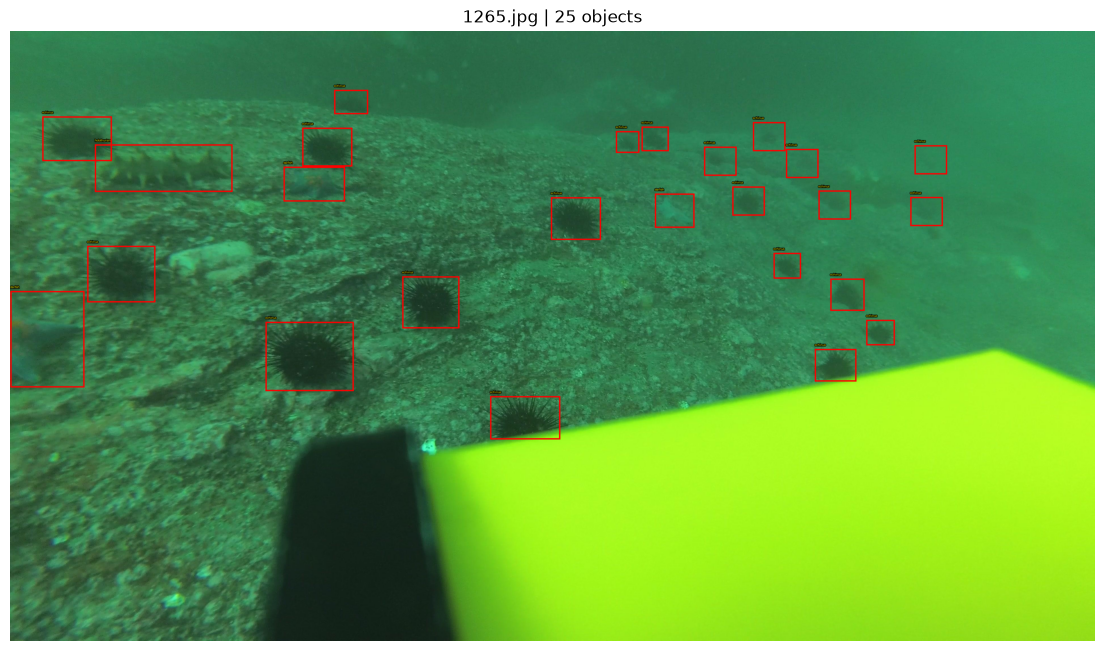

In [ ]:
#visualizing cleaned bounding boxes
import random
from collections import defaultdict
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

image_lookup = { # create a lookup dictionary to map image IDs to image information for the cleaned training dataset
    image["id"]: image
    for image in clean_train_data["images"]
}

annotations_by_image = defaultdict(list) # create a defaultdict to group annotations by image ID for the cleaned training dataset

for annotation in clean_train_data["annotations"]: # iterate through each annotation in the cleaned training dataset and group them by image ID
    annotations_by_image[annotation["image_id"]].append(annotation)

category_lookup = { # create a lookup dictionary to map category IDs to names for the cleaned training dataset
    category["id"]: category["name"]
    for category in clean_train_data["categories"]
}

# Only choose images that actually contain annotations
annotated_image_ids = [
    image_id
    for image_id, annotations in annotations_by_image.items()
    if len(annotations) > 0
]

selected_image_id = random.choice(annotated_image_ids) # randomly select an image ID from the list of annotated image IDs
image_record = image_lookup[selected_image_id]

image_path = next( # find the path to the selected image file in the DUO dataset
    DUO_ROOT.rglob(Path(image_record["file_name"]).name)
)

image = Image.open(image_path).convert("RGB") # open the selected image file and convert it to RGB format
draw = ImageDraw.Draw(image)

for annotation in annotations_by_image[selected_image_id]: # iterate through each annotation for the selected image and draw the bounding boxes and class names on the image
    x, y, width, height = annotation["bbox"]
    class_name = category_lookup[annotation["category_id"]]

    draw.rectangle( # draw a rectangle around the bounding box on the image
        [x, y, x + width, y + height],
        outline="red",
        width=5,
    )

    draw.text( # draw the class name above the bounding box on the image
        (x, max(0, y - 20)),
        class_name,
        fill="yellow",
        stroke_width=2,
        stroke_fill="black",
    )

print("Image ID:", selected_image_id) # print the ID of the selected image
print("File:", image_record["file_name"])
print(
    "Number of annotations:",
    len(annotations_by_image[selected_image_id])
)

plt.figure(figsize=(14, 9)) # create a new figure with a specified size for displaying the image with bounding boxes
plt.imshow(image)
plt.axis("off")
plt.title(
    f"{image_record['file_name']} | "
    f"{len(annotations_by_image[selected_image_id])} objects"
)
plt.show() # display the image with bounding boxes and class names

Recorded dimensions: 1920 x 1080
Actual dimensions: 1920 x 1080
Image ID: 6427
File: 6427.jpg
Image path: d:\underwater-object-detection\data\raw\DUO\images\train\6427.jpg
Number of annotations: 7


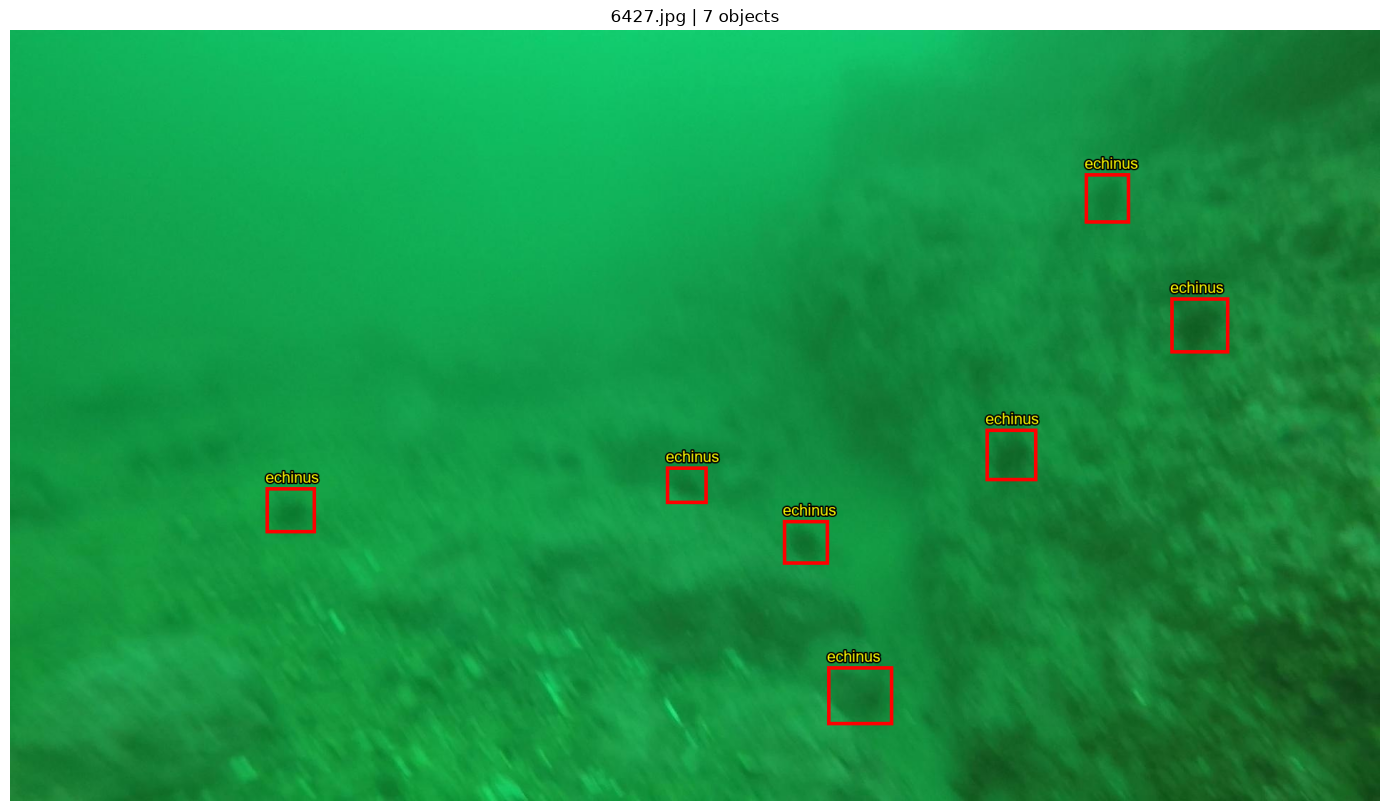

In [42]:
#additonal validation to ensure no invalid boxes remain after cleaning
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont


# Location of the official DUO training images
TRAIN_IMAGE_DIR = DUO_ROOT / "images" / "train"


# Create a lookup for image information
image_lookup = {
    image["id"]: image
    for image in clean_train_data["images"]
}


# Group annotations by image ID
annotations_by_image = defaultdict(list)

for annotation in clean_train_data["annotations"]:
    annotations_by_image[annotation["image_id"]].append(annotation)


# Create a lookup between category IDs and class names
category_lookup = {
    category["id"]: category["name"]
    for category in clean_train_data["categories"]
}


# Select only images containing annotations
annotated_image_ids = [
    image_id
    for image_id, annotations in annotations_by_image.items()
    if annotations
]


# Select a random annotated image
selected_image_id = random.choice(annotated_image_ids)
image_record = image_lookup[selected_image_id]


# Use the training folder specifically
image_path = TRAIN_IMAGE_DIR / image_record["file_name"]

if not image_path.exists():
    raise FileNotFoundError(
        f"Could not find image: {image_path}"
    )


# Load the image
image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)


# Check that recorded and actual dimensions agree
print(
    "Recorded dimensions:",
    image_record["width"],
    "x",
    image_record["height"],
)

print("Actual dimensions:", image.width, "x", image.height)


# Load a readable font
try:
    font = ImageFont.truetype("arial.ttf", 22)
except OSError:
    font = ImageFont.load_default()


# Draw bounding boxes and labels
for annotation in annotations_by_image[selected_image_id]:
    x, y, width, height = annotation["bbox"]

    x_min = int(round(x))
    y_min = int(round(y))
    x_max = int(round(x + width))
    y_max = int(round(y + height))

    class_name = category_lookup[annotation["category_id"]]

    draw.rectangle(
        [x_min, y_min, x_max, y_max],
        outline="red",
        width=5,
    )

    draw.text(
        (x_min, max(0, y_min - 26)),
        class_name,
        fill="yellow",
        font=font,
        stroke_width=2,
        stroke_fill="black",
    )


number_of_annotations = len(
    annotations_by_image[selected_image_id]
)

print("Image ID:", selected_image_id)
print("File:", image_record["file_name"])
print("Image path:", image_path)
print("Number of annotations:", number_of_annotations)


plt.figure(figsize=(14, 9))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"{image_record['file_name']} | "
    f"{number_of_annotations} objects"
)
plt.tight_layout()
plt.show()

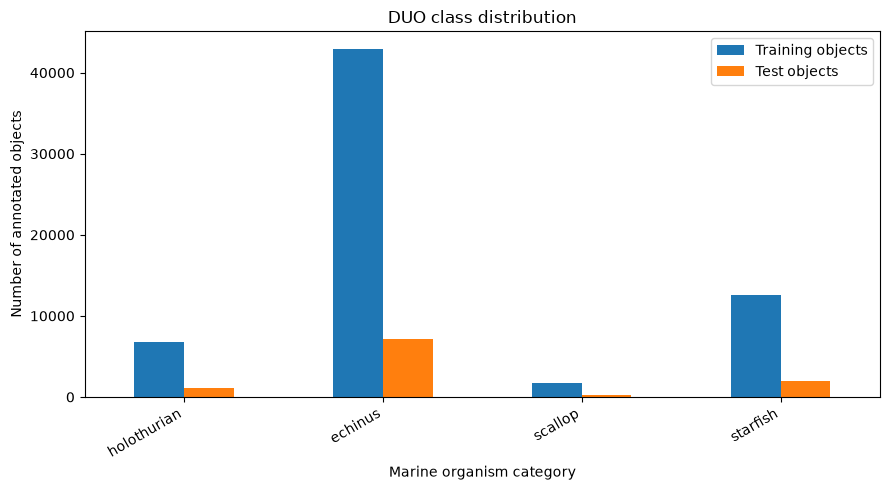

Saved table: d:\underwater-object-detection\results\duo_class_distribution.csv
Saved figure: d:\underwater-object-detection\figures\class_distributions\duo_class_distribution.png


In [ ]:
#calculating class distribution after cleaning
from collections import Counter
import pandas as pd

category_lookup = { # dictionary to map category IDs to names for the cleaned training dataset
    category["id"]: category["name"]
    for category in clean_train_data["categories"]
}

train_class_counts = Counter( # count the number of training annotations for each class in the cleaned training dataset
    category_lookup[annotation["category_id"]]
    for annotation in clean_train_data["annotations"]
)

test_class_counts = Counter( # count the number of test annotations for each class in the cleaned test dataset
    category_lookup[annotation["category_id"]]
    for annotation in clean_test_data["annotations"]
)

class_table = pd.DataFrame({ # create a DataFrame to display the class distribution after cleaning
    "Class": list(category_lookup.values()),
    "Training objects": [
        train_class_counts[name]
        for name in category_lookup.values()
    ],
    "Test objects": [ # create a list of test object counts for each class
        test_class_counts[name]
        for name in category_lookup.values()
    ],
})

class_table["Total objects"] = ( # calculate the total number of objects for each class by summing training and test objects
    class_table["Training objects"]
    + class_table["Test objects"]
)

class_table["Training percentage"] = ( # calculate the percentage of training objects for each class
    class_table["Training objects"]
    / class_table["Training objects"].sum()
    * 100
).round(2)

class_table # display the class distribution table after cleaning


#to plot it
import matplotlib.pyplot as plt

ax = class_table.plot(
    x="Class",
    y=["Training objects", "Test objects"],
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("DUO class distribution")
ax.set_xlabel("Marine organism category")
ax.set_ylabel("Number of annotated objects")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



#to save it
output_table = (
    PROJECT_ROOT
    / "results"
    / "duo_class_distribution.csv"
)

class_table.to_csv(output_table, index=False)

figure_path = (
    PROJECT_ROOT
    / "figures"
    / "class_distributions"
    / "duo_class_distribution.png"
)

figure_path.parent.mkdir(parents=True, exist_ok=True)

ax.figure.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

print("Saved table:", output_table)
print("Saved figure:", figure_path)

In [ ]:
#creating validation split from training data using an 80-20 split
from sklearn.model_selection import train_test_split

all_train_image_ids = [ # create a list of all image IDs in the cleaned training dataset
    image["id"]
    for image in clean_train_data["images"]
]

train_ids, val_ids = train_test_split( # split the cleaned training dataset into training and validation sets using an 80-20 split
    all_train_image_ids,
    test_size=0.20,
    random_state=42,
    shuffle=True,
)

print("Training images:", len(train_ids)) # print the number of training images and validation images after the split
print("Validation images:", len(val_ids)) # print the number of validation images after the split
print("Official test images:", len(clean_test_data["images"])) # print the number of official test images in the cleaned test dataset



#saving the splits
split_dir = PROJECT_ROOT / "data" / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

image_name_lookup = { # create a lookup dictionary to map image IDs to file names for the cleaned training dataset
    image["id"]: image["file_name"] # map each image ID to its corresponding file name
    for image in clean_train_data["images"] # iterate through each image in the cleaned training dataset and create a mapping of image IDs to file names
}

train_names = [ # create a list of training image file names based on the training image IDs    
    image_name_lookup[image_id]
    for image_id in train_ids
]

val_names = [ # create a list of validation image file names based on the validation image IDs
    image_name_lookup[image_id]
    for image_id in val_ids
]

test_names = [ # create a list of test image file names based on the cleaned test dataset
    image["file_name"]
    for image in clean_test_data["images"]
]

(split_dir / "train.txt").write_text( # write the training image file names to a text file in the splits directory
    "\n".join(train_names),
    encoding="utf-8",
)

(split_dir / "val.txt").write_text( # write the validation image file names to a text file in the splits directory
    "\n".join(val_names),
    encoding="utf-8",
)

(split_dir / "test.txt").write_text( # write the test image file names to a text file in the splits directory
    "\n".join(test_names),
    encoding="utf-8",
)

print("Saved split files to:", split_dir) # print the path where the split files were saved




#checking class balance between training and validation splits
from collections import Counter

train_id_set = set(train_ids) # create a set of training image IDs for faster lookup
val_id_set = set(val_ids)

train_split_counts = Counter() # create a Counter to count the number of training annotations for each class in the training split
val_split_counts = Counter() # create a Counter to count the number of validation annotations for each class in the validation split

for annotation in clean_train_data["annotations"]: # iterate through each annotation in the cleaned training dataset and count the number of annotations for each class in the training and validation splits
    class_name = category_lookup[annotation["category_id"]] # get the class name for the current annotation based on its category ID    

    if annotation["image_id"] in train_id_set: # if the image ID of the current annotation is in the training split, increment the count for that class in the training split
        train_split_counts[class_name] += 1

    elif annotation["image_id"] in val_id_set: # if the image ID of the current annotation is in the validation split, increment the count for that class in the validation split
        val_split_counts[class_name] += 1

split_class_table = pd.DataFrame({ # create a DataFrame to display the class distribution between the training and validation splits
    "Class": list(category_lookup.values()),
    "Train objects": [
        train_split_counts[name]
        for name in category_lookup.values()
    ],
    "Validation objects": [ # create a list of validation object counts for each class
        val_split_counts[name]
        for name in category_lookup.values()
    ],
})

split_class_table # display the class distribution table between the training and validation splits

Training images: 5336
Validation images: 1335
Official test images: 1111
Saved split files to: d:\underwater-object-detection\data\splits


,Class,Train objects,Validation objects
0,holothurian,5466,1342
1,echinus,34583,8371
2,scallop,1392,315
3,starfish,10059,2469


In [ ]:
#converting DUO from cleaned COCO format to YOLO format to run YOLOv8 training
from pathlib import Path
import shutil

YOLO_ROOT = PROJECT_ROOT / "data" / "processed" / "DUO_yolo"

for split in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

print("YOLO folders created at:", YOLO_ROOT)



#Category mapping between COCO and YOLO formats
# COCO category IDs begin at 1, while YOLO class IDs begin at 0
coco_to_yolo_class = {
    1: 0,  # holothurian
    2: 1,  # echinus
    3: 2,  # scallop
    4: 3,  # starfish
}

yolo_class_names = [
    "holothurian",
    "echinus",
    "scallop",
    "starfish",
]

#CINVERSION FUNCTION
def coco_bbox_to_yolo(bbox, image_width, image_height):
    """
    Convert COCO [x, y, width, height]
    to YOLO [x_center, y_center, width, height],
    normalised to values between 0 and 1.
    """
    x, y, width, height = bbox

    x_center = (x + width / 2) / image_width
    y_center = (y + height / 2) / image_height
    norm_width = width / image_width
    norm_height = height / image_height

    return x_center, y_center, norm_width, norm_height

#CONVERTING TRAINING AND VALIDATION SPLITS
from collections import defaultdict

train_annotations_by_image = defaultdict(list)

for annotation in clean_train_data["annotations"]:
    train_annotations_by_image[annotation["image_id"]].append(annotation) # group annotations by image ID for the cleaned training dataset

train_image_lookup = { # create a lookup dictionary to map image IDs to image information for the cleaned training dataset
    image["id"]: image
    for image in clean_train_data["images"]
}

TRAIN_IMAGE_DIR = DUO_ROOT / "images" / "train" # define the path to the training images in the DUO dataset

def write_yolo_split(image_ids, split_name): # define a function to write the YOLO formatted data for a given split (training or validation)
    image_output_dir = YOLO_ROOT / "images" / split_name # define the output directory for the images in the YOLO format
    label_output_dir = YOLO_ROOT / "labels" / split_name # define the output directory for the labels in the YOLO format

    written_images = 0 # initialize counters for the number of images and labels written
    written_labels = 0

    for image_id in image_ids: # iterate through each image ID in the given split
        image_record = train_image_lookup[image_id]
        file_name = image_record["file_name"]

        source_image = TRAIN_IMAGE_DIR / file_name # define the source path of the image in the DUO dataset
        destination_image = image_output_dir / file_name

        if not source_image.exists(): # check if the source image exists, and raise a FileNotFoundError if it does not
            raise FileNotFoundError(source_image)

        # Copy the image into the YOLO structure
        shutil.copy2(source_image, destination_image)
        written_images += 1

        label_path = label_output_dir / f"{Path(file_name).stem}.txt" # define the path for the label file in the YOLO format

        label_lines = [] # initialise list to store the label lines for the current image

        for annotation in train_annotations_by_image.get(image_id, []): # iterate through each annotation for the current image ID and convert the bounding box to YOLO format
            yolo_class = coco_to_yolo_class[annotation["category_id"]]

            x_center, y_center, width, height = coco_bbox_to_yolo( # convert the COCO bounding box to YOLO format using the coco_bbox_to_yolo function
                annotation["bbox"],
                image_record["width"],
                image_record["height"],
            )

            label_lines.append( # append the YOLO formatted label line for the current annotation to the label_lines list
                f"{yolo_class} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}"
            )

        label_path.write_text( # write the YOLO formatted label lines to the label file in the YOLO format
            "\n".join(label_lines),
            encoding="utf-8",
        )

        written_labels += 1 # increment the counter for the number of label files written

    print(
        f"{split_name}: "
        f"{written_images} images, "
        f"{written_labels} label files"
    )

    #TO RUN
    write_yolo_split(train_ids, "train")
write_yolo_split(val_ids, "val")


#OFFICIAL TEST SET 
test_annotations_by_image = defaultdict(list)

for annotation in clean_test_data["annotations"]: # group annotations by image ID for the cleaned test dataset
    test_annotations_by_image[annotation["image_id"]].append(annotation)

test_image_lookup = { # create a lookup dictionary to map image IDs to image information for the cleaned test dataset
    image["id"]: image
    for image in clean_test_data["images"]
}

TEST_IMAGE_DIR = DUO_ROOT / "images" / "test" # define the path to the test images in the DUO dataset

def write_yolo_test_split(): # define a function to write the YOLO formatted data for the official test split
    image_output_dir = YOLO_ROOT / "images" / "test"
    label_output_dir = YOLO_ROOT / "labels" / "test"

    for image_id, image_record in test_image_lookup.items(): # iterate through each image ID and its corresponding image record in the cleaned test dataset
        file_name = image_record["file_name"]

        source_image = TEST_IMAGE_DIR / file_name # define the source path of the image in the DUO dataset
        destination_image = image_output_dir / file_name

        if not source_image.exists(): # check if the source image exists, and raise a FileNotFoundError if it does not
            raise FileNotFoundError(source_image)

        shutil.copy2(source_image, destination_image) # copy the image into the YOLO structure

        label_lines = [] # initialise a list to store the label lines for the current image

        for annotation in test_annotations_by_image.get(image_id, []): # iterate through each annotation for the current image ID and convert the bounding box to YOLO format
            yolo_class = coco_to_yolo_class[annotation["category_id"]]

            x_center, y_center, width, height = coco_bbox_to_yolo( # convert the COCO bounding box to YOLO format using the coco_bbox_to_yolo function
                annotation["bbox"],
                image_record["width"],
                image_record["height"],
            )

            label_lines.append( # append the YOLO formatted label line for the current annotation to the label_lines list
                f"{yolo_class} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}"
            )

        label_path = ( # define the path for the label file in the YOLO format
            label_output_dir
            / f"{Path(file_name).stem}.txt"
        )

        label_path.write_text( # write the YOLO formatted label lines to the label file in the YOLO format
            "\n".join(label_lines),
            encoding="utf-8",
        )

    print("Test split completed") # print a message indicating that the official test split has been completed


    #TO RUN
    write_yolo_test_split()


    #CHECKING COUNTS
    for split in ["train", "val", "test"]:
        image_count = len(
        list((YOLO_ROOT / "images" / split).glob("*"))
    )

    label_count = len(
        list((YOLO_ROOT / "labels" / split).glob("*.txt"))
    )

    print(
        split,
        "| images:",
        image_count,
        "| labels:",
        label_count,
    )

YOLO folders created at: d:\underwater-object-detection\data\processed\DUO_yolo
val: 1335 images, 1335 label files
train: 5336 images, 5336 label files
train: 5336 images, 5336 label files
train: 5336 images, 5336 label files
train: 5336 images, 5336 label files
train: 5336 images, 5336 label files
train: 5336 images, 5336 label files
